# Modélisation LSTM pour la Prédiction du Rendement du Maïs en Afrique

Modèle LSTM (PyTorch) avec normalisation par pays, séquence de **10 pas de temps**, architecture améliorée : LSTM bidirectionnel (3 couches, hidden=128) + attention multi-tête + MLP profond GELU + skip connection + PeakAwareLoss (MSE + Quantile) + ReduceLROnPlateau.

## Bibliothèques

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

print("PyTorch version:", torch.__version__)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

PyTorch version: 2.8.0+cpu
Device: cpu


## 1. Chargement et Exploration des Données

In [15]:
dataset = pd.read_csv("./data/maize_dataset_africa_full.csv")
print(len(dataset))
dataset.head()

3014


,country,year,rainfall_mm,avg_temp_c,harvested_area_ha,production_tonnes,yield_t_ha
0,Algeria,1961,31.18,22.36,537680.0,524022.928000,0.9746
1,Algeria,1962,-123.77,22.90,504616.0,272492.640000,0.5400
2,Algeria,1963,133.53,22.08,530460.0,568440.989046,1.0716
3,Algeria,1964,174.50,22.50,502449.0,588016.114945,1.1703
4,Algeria,1965,476.94,22.38,575006.0,632506.600000,1.1000


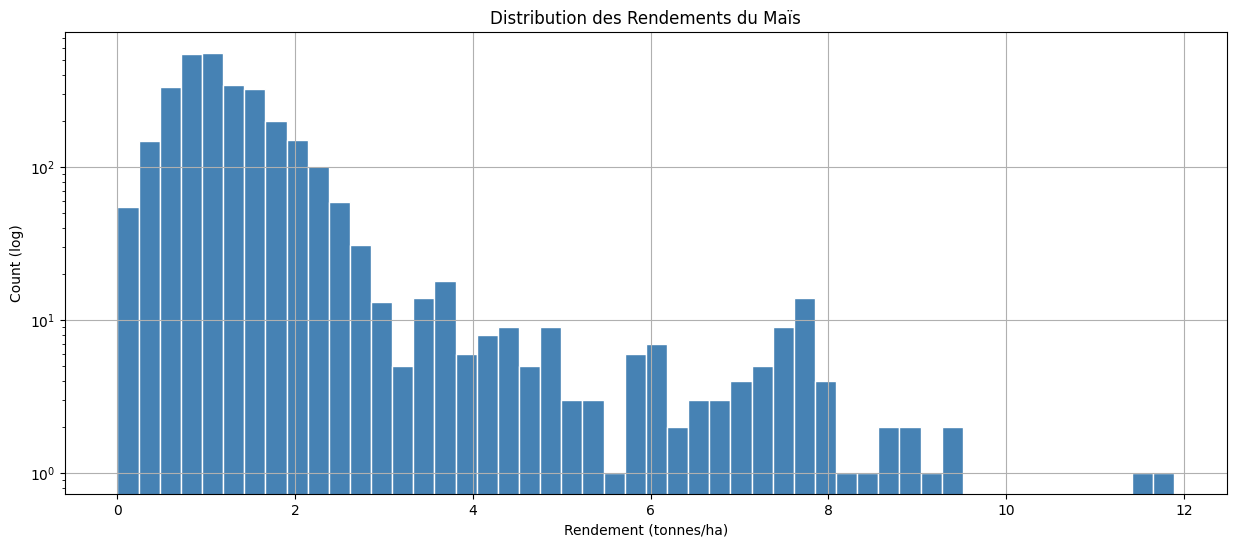

In [16]:
plt.figure(figsize=(15, 6))
plt.hist(dataset['yield_t_ha'].dropna(), bins=50, color='steelblue', edgecolor='white')
plt.yscale('log')
plt.title("Distribution des Rendements du Maïs")
plt.xlabel("Rendement (tonnes/ha)")
plt.ylabel("Count (log)")
plt.grid()
plt.show()

## 2. Preprocessing

### Encodage des pays

In [17]:
encoder = LabelEncoder()
dataset["country_encoded"] = encoder.fit_transform(dataset["country"])
dataset.head()

,country,year,rainfall_mm,avg_temp_c,harvested_area_ha,production_tonnes,yield_t_ha,country_encoded
0,Algeria,1961,31.18,22.36,537680.0,524022.928000,0.9746,0
1,Algeria,1962,-123.77,22.90,504616.0,272492.640000,0.5400,0
2,Algeria,1963,133.53,22.08,530460.0,568440.989046,1.0716,0
3,Algeria,1964,174.50,22.50,502449.0,588016.114945,1.1703,0
4,Algeria,1965,476.94,22.38,575006.0,632506.600000,1.1000,0


### Features & Target

In [19]:
dataset = dataset.sort_values(["country", "year"])
dataset["yield_t_ha_lag1"] = dataset.groupby("country")["yield_t_ha"].shift(1)
dataset["yield_t_ha_lag2"] = dataset.groupby("country")["yield_t_ha"].shift(2)

# Variation annuelle du rendement (momentum)
dataset["yield_t_ha_delta"] = dataset.groupby("country")["yield_t_ha"].diff()

features = [
    "country_encoded",
    "year",
    "rainfall_mm",
    "avg_temp_c",
    "harvested_area_ha",
    "yield_t_ha_lag1",  # année précédente
    "yield_t_ha_lag2",  # il y a 2 ans
    "yield_t_ha_delta",   # variation annuelle
]

target = "yield_t_ha"

print(dataset[features + [target]].isna().sum())

country_encoded        0
year                   0
rainfall_mm            0
avg_temp_c             0
harvested_area_ha      0
yield_t_ha_lag1       50
yield_t_ha_lag2      100
yield_t_ha_delta      50
yield_t_ha             0
dtype: int64


In [20]:
dataset = dataset.groupby("country", group_keys=False).apply(
    lambda g: g.fillna(method="ffill").fillna(method="bfill")
).reset_index(drop=True)

print(dataset[features + [target]].isna().sum())

country_encoded      0
year                 0
rainfall_mm          0
avg_temp_c           0
harvested_area_ha    0
yield_t_ha_lag1      0
yield_t_ha_lag2      0
yield_t_ha_delta     0
yield_t_ha           0
dtype: int64


C:\Users\sonwa\AppData\Local\Temp\ipykernel_4312\2692164512.py:2: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  lambda g: g.fillna(method="ffill").fillna(method="bfill")
C:\Users\sonwa\AppData\Local\Temp\ipykernel_4312\2692164512.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  dataset = dataset.groupby("country", group_keys=False).apply(


### Normalisation PAR PAYS

In [21]:
scalers_per_country = {}

dataset_normalized = dataset.copy()

countries = dataset["country"].unique()
features_to_scale = [f for f in features if f != "country_encoded"]

for country in countries:
    mask = dataset_normalized["country"] == country
    country_data = dataset_normalized.loc[mask, features_to_scale + [target]].copy()

    scaler = MinMaxScaler()
    country_data[features_to_scale + [target]] = scaler.fit_transform(
        country_data[features_to_scale + [target]]
    )

    dataset_normalized.loc[mask, features_to_scale + [target]] = country_data[features_to_scale + [target]].values
    scalers_per_country[country] = scaler

# Normaliser country_encoded
ce_scaler = MinMaxScaler()
dataset_normalized["country_encoded"] = ce_scaler.fit_transform(
    dataset_normalized[["country_encoded"]]
)

print(f"Scalers créés pour {len(scalers_per_country)} pays")
dataset_normalized[features + [target]].describe()

C:\Users\sonwa\AppData\Local\Temp\ipykernel_4312\2801360195.py:17: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[0.         0.01587302 0.03174603 0.04761905 0.06349206 0.07936508
 0.0952381  0.11111111 0.12698413 0.14285714 0.15873016 0.17460317
 0.19047619 0.20634921 0.22222222 0.23809524 0.25396825 0.26984127
 0.28571429 0.3015873  0.31746032 0.33333333 0.34920635 0.36507937
 0.38095238 0.3968254  0.41269841 0.42857143 0.44444444 0.46031746
 0.47619048 0.49206349 0.50793651 0.52380952 0.53968254 0.55555556
 0.57142857 0.58730159 0.6031746  0.61904762 0.63492063 0.65079365
 0.66666667 0.68253968 0.6984127  0.71428571 0.73015873 0.74603175
 0.76190476 0.77777778 0.79365079 0.80952381 0.82539683 0.84126984
 0.85714286 0.87301587 0.88888889 0.9047619  0.92063492 0.93650794
 0.95238095 0.96825397 0.98412698 1.        ]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.


Scalers créés pour 50 pays


,country_encoded,year,rainfall_mm,avg_temp_c,harvested_area_ha,yield_t_ha_lag1,yield_t_ha_lag2,yield_t_ha_delta,yield_t_ha
count,3014.000000,3014.000000,3014.000000,3014.000000,3014.000000,3014.000000,3014.000000,3014.000000,3014.000000
mean,0.491550,0.500000,0.505353,0.499936,0.496704,0.422252,0.421421,0.478849,0.428022
std,0.293499,0.293565,0.229888,0.233914,0.279423,0.268212,0.271328,0.191605,0.268026
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.224490,0.250000,0.346002,0.334523,0.260888,0.204037,0.202201,0.362808,0.209570
50%,0.489796,0.500000,0.504252,0.498168,0.495748,0.382335,0.379696,0.482392,0.390935
75%,0.734694,0.750000,0.663053,0.666667,0.729713,0.622381,0.623256,0.582096,0.628164
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


### Création des séquences (SEQUENCE_LENGTH = 5)

In [22]:
SEQUENCE_LENGTH = 10  # Augmenté de 5→10 pour capturer plus d'historique

X = []
y = []

for country in countries:
    country_data = dataset_normalized[
        dataset_normalized["country"] == country
    ].sort_values("year")

    values = country_data[features + [target]].values

    if len(values) <= SEQUENCE_LENGTH:
        continue

    for i in range(len(values) - SEQUENCE_LENGTH):
        seq = values[i:i + SEQUENCE_LENGTH]
        target_value = values[i + SEQUENCE_LENGTH, -1]
        X.append(seq[:, :-1])
        y.append(target_value)

X = np.array(X, dtype=np.float32)
y = np.array(y, dtype=np.float32)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (2764, 5, 8)
y shape: (2764,)


### Train / Test Split (temporel — pas de shuffle)

In [23]:
split = int(len(X) * 0.8)

train_x, test_x = X[:split], X[split:]
train_y, test_y = y[:split], y[split:]

print("Train X shape:", train_x.shape)
print("Train Y shape:", train_y.shape)
print("Test X shape:", test_x.shape)
print("Test Y shape:", test_y.shape)

Train X shape: (2211, 5, 8)
Train Y shape: (2211,)
Test X shape: (553, 5, 8)
Test Y shape: (553,)


### Dataset & DataLoader PyTorch

In [24]:
class MaizeDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32).unsqueeze(1)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


train_dataset = MaizeDataset(train_x, train_y)
test_dataset  = MaizeDataset(test_x,  test_y)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False)

print(f"Train batches : {len(train_loader)}")
print(f"Test  batches : {len(test_loader)}")

Train batches : 70
Test  batches : 18


## 3. Modèle LSTM (PyTorch)

In [25]:
class LSTMModel(nn.Module):
    """
    Améliorations vs version précédente :
      - hidden_size 64→128 : plus de capacité
      - num_layers 2→3 : hiérarchie temporelle plus profonde
      - Attention multi-tête (multi-head) remplace l'attention scalaire
      - Tête MLP non-linéaire (3 couches) pour capturer les non-linéarités/pics
      - LayerNorm à la place de BatchNorm (plus stable sur séries temporelles)
      - Résidu (skip connection) entre l'entrée de la tête et la sortie intermédiaire
    """
    def __init__(self, input_size, hidden_size=128, num_layers=3, dropout=0.2, n_heads=4):
        super(LSTMModel, self).__init__()

        self.lstm = nn.LSTM(
            input_size,
            hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout,
            bidirectional=True,
        )
        lstm_out_size = hidden_size * 2  # bidirectionnel

        # --- Attention multi-tête ---
        self.attn = nn.MultiheadAttention(
            embed_dim=lstm_out_size,
            num_heads=n_heads,
            dropout=dropout,
            batch_first=True
        )
        self.ln1 = nn.LayerNorm(lstm_out_size)

        # --- Tête de régression MLP profonde (non-linéaire) ---
        self.fc1   = nn.Linear(lstm_out_size, 128)
        self.act1  = nn.GELU()              # GELU > ReLU pour capturer les pics
        self.drop1 = nn.Dropout(dropout)
        self.fc2   = nn.Linear(128, 64)
        self.act2  = nn.GELU()
        self.drop2 = nn.Dropout(dropout)
        self.fc3   = nn.Linear(64, 1)

        # Skip connection pour éviter l'écrasement des variations
        self.skip = nn.Linear(lstm_out_size, 1)

    def forward(self, x):
        lstm_out, _ = self.lstm(x)           # (batch, seq, lstm_out_size)

        # Attention multi-tête (self-attention sur les pas de temps)
        attn_out, _ = self.attn(lstm_out, lstm_out, lstm_out)
        attn_out = self.ln1(attn_out + lstm_out)  # résidu + norm

        # Agréger sur la dimension temporelle (mean pooling)
        context = attn_out.mean(dim=1)       # (batch, lstm_out_size)

        # MLP profond
        h = self.drop1(self.act1(self.fc1(context)))
        h = self.drop2(self.act2(self.fc2(h)))
        out = self.fc3(h)

        # Skip connection
        out = out + self.skip(context)
        return out


input_size = train_x.shape[2]
model = LSTMModel(input_size=input_size).to(device)
print(model)
print(f"\nParamètres entraînables : {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")


LSTMModel(
  (lstm): LSTM(8, 64, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
  (attention): Linear(in_features=128, out_features=1, bias=True)
  (bn): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (drop): Dropout(p=0.3, inplace=False)
  (fc1): Linear(in_features=128, out_features=32, bias=True)
  (act): ReLU()
  (fc2): Linear(in_features=32, out_features=1, bias=True)
)

Paramètres entraînables : 141,762


## 4. Entraînement

In [26]:
import os
os.makedirs('./model', exist_ok=True)

# MSE + pénalité sur les pics (quantile loss custom)
class PeakAwareLoss(nn.Module):
    """
    Combine MSE (précision globale) + Quantile loss asymétrique (capture les pics).
    alpha contrôle la pondération vers les valeurs élevées.
    """
    def __init__(self, alpha=0.7):
        super().__init__()
        self.alpha = alpha

    def forward(self, pred, target):
        err = target - pred
        mse = (err ** 2).mean()
        # Quantile loss : pénalise plus les sous-estimations (pics manqués)
        q_loss = torch.where(err >= 0,
                             self.alpha * err.abs(),
                             (1 - self.alpha) * err.abs()).mean()
        return 0.6 * mse + 0.4 * q_loss


criterion = PeakAwareLoss(alpha=0.7)

# AdamW + ReduceLROnPlateau
optimizer = torch.optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=8, min_lr=1e-5
)

EPOCHS         = 150  # Plus d'époques, early stopping gère
PATIENCE       = 25
best_val_loss  = float("inf")
patience_counter = 0
best_weights   = None
train_losses   = []
val_losses     = []

val_size = int(0.2 * len(train_x))
tr_x = torch.tensor(train_x[:-val_size], dtype=torch.float32)
tr_y = torch.tensor(train_y[:-val_size], dtype=torch.float32).unsqueeze(1)
vl_x = torch.tensor(train_x[-val_size:], dtype=torch.float32).to(device)
vl_y = torch.tensor(train_y[-val_size:], dtype=torch.float32).unsqueeze(1).to(device)

tr_loader = DataLoader(
    torch.utils.data.TensorDataset(tr_x, tr_y),
    batch_size=32, shuffle=True  # shuffle=True améliore la généralisation
)

for epoch in range(1, EPOCHS + 1):

    model.train()
    train_loss = 0.0
    for X_batch, y_batch in tr_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        preds = model(X_batch)
        loss  = criterion(preds, y_batch)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        train_loss += loss.item() * len(X_batch)
    train_loss /= len(tr_x)

    model.eval()
    with torch.no_grad():
        val_preds = model(vl_x)
        val_loss  = criterion(val_preds, vl_y).item()

    scheduler.step(val_loss)  # Réduit le LR si stagnation

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    if val_loss < best_val_loss:
        best_val_loss    = val_loss
        patience_counter = 0
        best_weights     = {k: v.clone() for k, v in model.state_dict().items()}
        torch.save(best_weights, "./model/best_model_weights.pt")
    else:
        patience_counter += 1

    if epoch % 20 == 0:
        print(f"Epoch {epoch:3d}/{EPOCHS} | Train: {train_loss:.6f} | Val: {val_loss:.6f} | LR: {optimizer.param_groups[0]['lr']:.2e}")

    if patience_counter >= PATIENCE:
        print(f"\nEarly stopping à l'epoch {epoch}")
        break

model.load_state_dict(best_weights)
print("\nMeilleurs poids restaurés.")


Epoch  20/100 | Train: 0.016382 | Val: 0.026023 | LR: 1.00e-03
Epoch  40/100 | Train: 0.014049 | Val: 0.027160 | LR: 1.00e-03
Epoch  60/100 | Train: 0.012750 | Val: 0.027541 | LR: 1.00e-03
Epoch  80/100 | Train: 0.011670 | Val: 0.022791 | LR: 1.00e-03

Early stopping à l'epoch 88

Meilleurs poids restaurés.


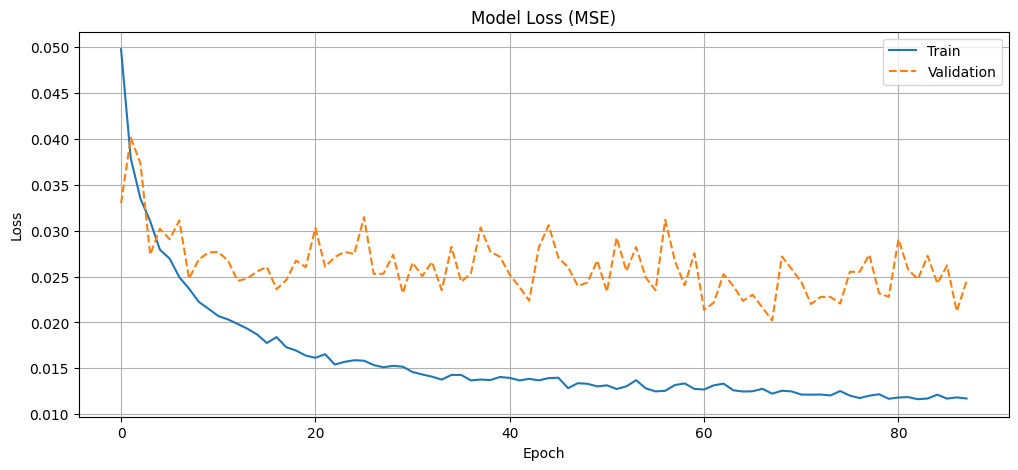

In [27]:
plt.figure(figsize=(12, 5))
plt.plot(train_losses, label='Train')
plt.plot(val_losses,   label='Validation', linestyle='--')
plt.title('Model Loss (MSE)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.grid()
plt.show()

## 5. Évaluation

In [28]:
model.eval()

all_preds = []
all_true  = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        preds   = model(X_batch).cpu().numpy().flatten()
        all_preds.extend(preds)
        all_true.extend(y_batch.numpy().flatten())

predictions_scaled = np.array(all_preds)
test_y_scaled      = np.array(all_true)

print(f"Prédictions shape : {predictions_scaled.shape}")

Prédictions shape : (553,)


In [30]:
# Reconstruire les labels pays pour chaque point test
all_country_labels = []
for country in countries:
    country_data = dataset_normalized[
        dataset_normalized["country"] == country
    ].sort_values("year")
    n = len(country_data) - SEQUENCE_LENGTH
    if n > 0:
        all_country_labels.extend([country] * n)

test_country_labels = all_country_labels[split:]

# Inverse transform par pays
features_to_scale = [f for f in features if f != "country_encoded"]
n_cols = len(features_to_scale) + 1   # features scalées + target

true_prices_real = []
pred_prices_real = []

for i, country in enumerate(test_country_labels):
    scaler = scalers_per_country[country]

    dummy_true = np.zeros((1, n_cols))
    dummy_pred = np.zeros((1, n_cols))
    dummy_true[0, -1] = test_y_scaled[i]
    dummy_pred[0, -1] = predictions_scaled[i]

    true_prices_real.append(scaler.inverse_transform(dummy_true)[0, -1])
    pred_prices_real.append(scaler.inverse_transform(dummy_pred)[0, -1])

true_prices_real = np.array(true_prices_real)
pred_prices_real = np.array(pred_prices_real)

mae  = mean_absolute_error(true_prices_real, pred_prices_real)
mse  = mean_squared_error(true_prices_real, pred_prices_real)
rmse = np.sqrt(mse)
r2   = r2_score(true_prices_real, pred_prices_real)

print(f"MAE  : {mae:.2f} tonne/ha")
print(f"MSE  : {mse:.2f}")
print(f"RMSE : {rmse:.2f} tonne/ha")
print(f"R²   : {r2:.4f}")

MAE  : 0.35 tonne/ha
MSE  : 0.23
RMSE : 0.48 tonne/ha
R²   : 0.6931


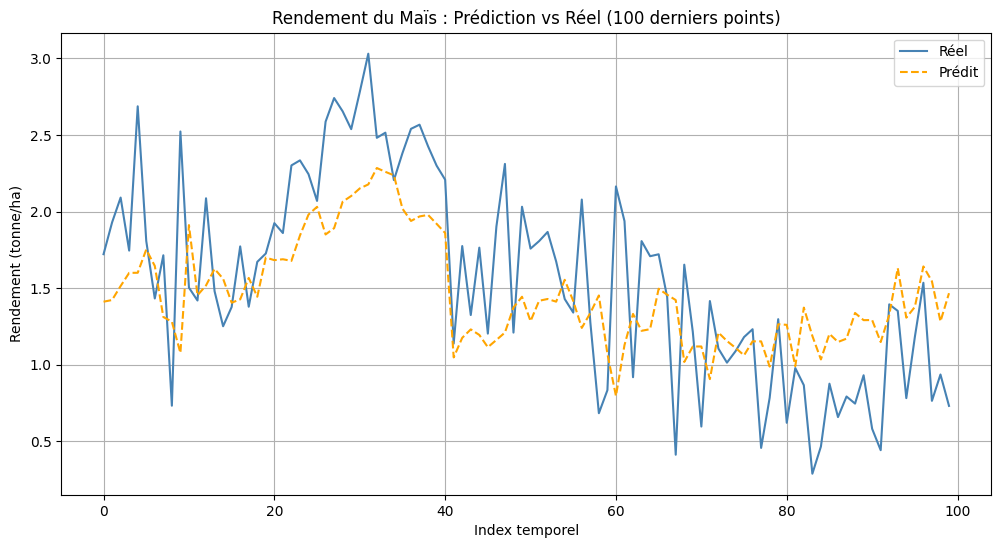

In [32]:
plt.figure(figsize=(12, 6))
plt.plot(true_prices_real[-100:], label='Réel',  color='steelblue')
plt.plot(pred_prices_real[-100:], label='Prédit', color='orange', linestyle='--')
plt.title('Rendement du Maïs : Prédiction vs Réel (100 derniers points)')
plt.xlabel('Index temporel')
plt.ylabel('Rendement (tonne/ha)')
plt.legend()
plt.grid()
plt.show()

## 6. Forecast Multi-Années


Forecast Cameroon (2025 → 2030) :
  2025 → 1.92 tonne/ha
  2026 → 1.94 tonne/ha
  2027 → 1.96 tonne/ha
  2028 → 1.98 tonne/ha
  2029 → 1.99 tonne/ha
  2030 → 2.01 tonne/ha


c:\Users\sonwa\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
c:\Users\sonwa\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
c:\Users\sonwa\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
c:\Users\sonwa\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
c:\Users\sonwa\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarni

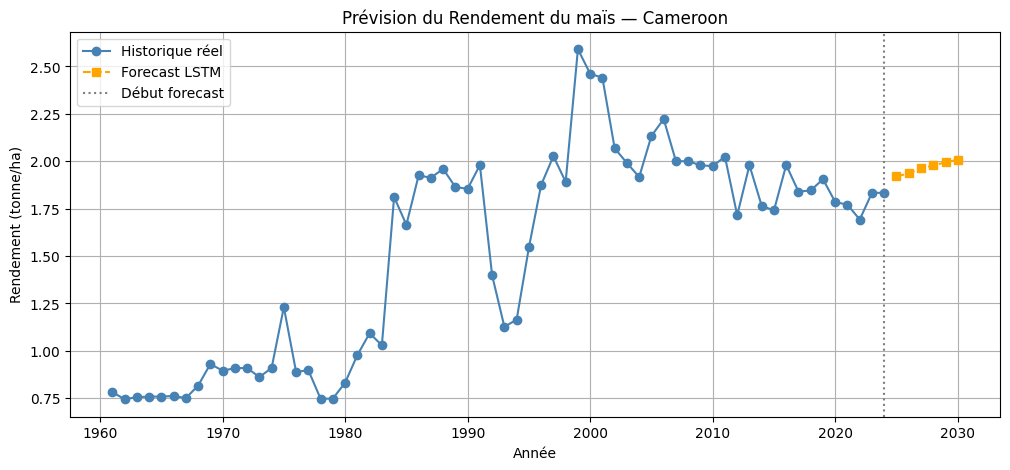

In [33]:
country = "Cameroon"
annee   = 2030

scaler = scalers_per_country[country]
features_to_scale = [f for f in features if f != "country_encoded"]
n_cols = len(features_to_scale) + 1

country_data_norm = dataset_normalized[
    dataset_normalized["country"] == country
].sort_values("year")

last_known_year = int(dataset[dataset["country"] == country]["year"].max())

if len(country_data_norm) < SEQUENCE_LENGTH:
    print("Pas assez de données pour la séquence")
elif annee <= last_known_year:
    print(f"Choisir une année > {last_known_year}")
else:
    # Séquence initiale = les SEQUENCE_LENGTH dernières années connues
    sequence     = country_data_norm[features].values[-SEQUENCE_LENGTH:].copy()
    year_col_idx = features.index("year")

    # Scaler global pour normaliser l'année correctement
    from sklearn.preprocessing import MinMaxScaler as _MMS
    _ys = _MMS()
    _ys.fit(dataset[["year"]])

    model.eval()
    predictions_forecast = []

    for year in range(last_known_year + 1, annee + 1):
        input_tensor = torch.tensor(sequence, dtype=torch.float32).unsqueeze(0).to(device)

        with torch.no_grad():
            pred_scaled = model(input_tensor).cpu().numpy()[0, 0]

        # Inverse transform → vrai prix USD/tonne
        dummy = np.zeros((1, n_cols))
        dummy[0, -1] = pred_scaled
        predicted_value = scaler.inverse_transform(dummy)[0, -1]
        predictions_forecast.append((year, predicted_value))

        # Mise à jour séquence
        new_row = sequence[-1].copy()

        # 1. Année : normalisée via scaler global
        new_row[year_col_idx] = _ys.transform([[year]])[0, 0]

        # 2. Glisser la fenêtre d'un pas
        sequence = np.vstack([sequence[1:], new_row])

    print(f"\nForecast {country} ({last_known_year + 1} → {annee}) :")
    for y, val in predictions_forecast:
        print(f"  {y} → {val:.2f} tonne/ha")

    # Visualisation avec historique réel en fond
    hist = dataset[dataset["country"] == country].sort_values("year")

    years_fc  = [p[0] for p in predictions_forecast]
    prices_fc = [p[1] for p in predictions_forecast]

    plt.figure(figsize=(12, 5))
    plt.plot(hist["year"], hist["yield_t_ha"],
             marker="o", color="steelblue", label="Historique réel")
    plt.plot(years_fc, prices_fc,
             marker="s", linestyle="--", color="orange", label="Forecast LSTM")
    plt.axvline(x=last_known_year, color="gray", linestyle=":", label="Début forecast")
    plt.title(f"Prévision du Rendement du maïs — {country}")
    plt.xlabel("Année")
    plt.ylabel("Rendement (tonne/ha)")
    plt.legend()
    plt.grid()
    plt.show()

## 8. Sauvegarde

In [ ]:
import joblib

# Sauvegarder le modèle PyTorch
# torch.save(model.state_dict(), "./model/model_africa_maize.pt")

# Sauvegarder architecture (pour recharger facilement)
# torch.save(model, "./model/model_africa_maize_full.pt")

# Sauvegarder scalers et encodeur
# joblib.dump(scalers_per_country, "./model/scalers_per_country.save")
# joblib.dump(encoder,             "./model/country_encoder.save")

# print("Modèle et scalers sauvegardés")

Modèle et scalers sauvegardés avec succès.
